# 2. Helps in Visualisation

## Basic Visualisation

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df = pd.read_csv("train.csv")

In [4]:
x = df.iloc[:,1:]
y = df.iloc[:,0]

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

### 1. Transforming to a 2D Coordinate System

In [6]:
# Transforming to a 2D Coordinate System

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.fit_transform(X_test)

In [7]:
X_train_trf

array([[-226.60523462, -305.89437099],
       [  38.33583717,  461.09152047],
       [-305.49225463,  351.67141678],
       ...,
       [ -28.00133402, -596.06287179],
       [ 233.97011308,  -18.64779077],
       [1096.50373629,  254.72333173]])

In [8]:
# Used Plotly for Dynamic Visualisation

import plotly.express as px

y_train_trf = y_train.astype(str)
fig = px.scatter(x=X_train_trf[:,0],
                 y=X_train_trf[:,1],
                 color=y_train_trf,
                 color_discrete_sequence=px.colors.qualitative.G10
                 )

fig.show()

### 2. Transforming to a 3D Coordinate System

In [9]:
# Transforming to a 3D Coordinate System

from sklearn.decomposition import PCA
pca = PCA(n_components=3)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.fit_transform(X_test)

In [10]:
X_train_trf

array([[-226.60523462, -305.89437099, -417.17563833],
       [  38.33583717,  461.09152047, -100.40840682],
       [-305.49225463,  351.67141678,  961.3475787 ],
       ...,
       [ -28.00133402, -596.06287179, -606.25130926],
       [ 233.97011308,  -18.64779077,  148.27481803],
       [1096.50373629,  254.72333173,  560.33354832]])

In [11]:
y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df,x=X_train_trf[:,0], y=X_train_trf[:,1], z=X_train_trf[:,2],
                 color=y_train_trf)
fig.update_layout(
    margin=dict(l=20, r = 20,t=20,b=20)
)

fig.show()

## Finding Optimum Number of Principle Components.

In [12]:
# Eigen Values

pca.explained_variance_

array([332483.68303166, 250952.54918209, 207256.97147675])

In [13]:
# Eigen Vector --> 3 vectors in 784 coordinates space

pca.components_.shape

(3, 784)

In [15]:
# Gives The Ratio of Eigen Vector for Explaining the Variance of Data.

pca.explained_variance_ratio_

array([0.09679375, 0.07305813, 0.06033733])

In [16]:
pca = PCA(n_components=None)
X_train_trf = pca.fit_transform(X_train)
X_test_trf = pca.fit_transform(X_test)

In [17]:
pca.explained_variance_.shape

(784,)

In [20]:
pca.components_.shape

(784, 784)

In [22]:
np.cumsum(pca.explained_variance_ratio_)

array([0.09679375, 0.16985188, 0.23018922, 0.28372663, 0.33277328,
       0.37445635, 0.40730698, 0.43645238, 0.46380296, 0.48834163,
       0.50960061, 0.53052469, 0.54785715, 0.56467637, 0.58054175,
       0.59518213, 0.60830893, 0.62111949, 0.63316753, 0.64470474,
       0.65539913, 0.6652386 , 0.67480078, 0.68387844, 0.69281602,
       0.70140566, 0.7093962 , 0.71727204, 0.72462711, 0.73134616,
       0.73790108, 0.74438366, 0.75034643, 0.75620175, 0.76188908,
       0.76729435, 0.77248311, 0.77747424, 0.78231798, 0.78711116,
       0.79163511, 0.79606282, 0.80035112, 0.80433162, 0.80827613,
       0.81208158, 0.81570048, 0.81921401, 0.82261171, 0.82594624,
       0.82917423, 0.83232796, 0.83528529, 0.83820854, 0.84106058,
       0.84378484, 0.84645204, 0.84903027, 0.85156111, 0.85405699,
       0.85648799, 0.8588554 , 0.86116512, 0.86336748, 0.86551237,
       0.86757766, 0.86961541, 0.87159945, 0.87353852, 0.8754295 ,
       0.87730045, 0.87914611, 0.88092195, 0.88263122, 0.88431

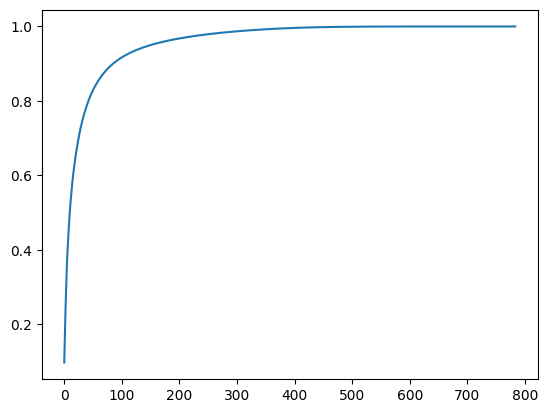

In [24]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))